# ECQL: LoRA против базовой модели

Перевод вопроса на русском в запрос на внутреннем языке ECQL.

Ноутбук работает в двух местах:
- **Google Colab, T4** - база грузится в 4 битах через bitsandbytes;
- **Mac, Apple Silicon** - bitsandbytes не работает, база грузится в bf16.

(я выполнял на маке)

Порядок: 
- самопроверка метрик, 
- два прогона базовой модели, 
- обучение адаптера,
- прогон с адаптером r=8, 
- прогон с адаптером r=4, 
- сравнение.

## 1. Окружение

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q \
        transformers==5.15.1 \
        peft==0.20.0 \
        trl==1.10.0 \
        accelerate==1.14.0 \
        datasets==5.0.1 \
        nltk==3.10.3 \
        matplotlib==3.11.1 \
        bitsandbytes

from importlib.metadata import PackageNotFoundError, version

for package in ("torch", "transformers", "peft", "trl", "accelerate", "datasets", "nltk", "matplotlib", "bitsandbytes"):
    try:
        print(f"{package:16} {version(package)}")
    except PackageNotFoundError:
        print(f"{package:16} не установлен")

torch            2.13.0
transformers     5.15.1
peft             0.20.0
trl              1.10.0
accelerate       1.14.0
datasets         5.0.1
nltk             3.10.3
matplotlib       3.11.1
bitsandbytes     не установлен


## 2. Код и данные

Часть кода по метрикам и генерации лежит в репозитории: `src/ecql_dataset`. 

В Colab репозиторий клонируется, локально берётся из каталога, где лежит ноутбук.

In [2]:
from pathlib import Path

REPO_URL = "https://github.com/samtakoy/llm-engineer-ecql-and-metrcis.git"

if IN_COLAB:
    ROOT = Path("/content") / Path(REPO_URL).stem
    if not ROOT.exists():
        !git clone -q {REPO_URL} {ROOT}
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()

sys.path.insert(0, str(ROOT / "src"))

DATASET = ROOT / "dataset" / "ecql"
OUTPUT = ROOT / "output"

print("корень:", ROOT)
print("датасет:", DATASET)

корень: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics
датасет: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/dataset/ecql


In [3]:
import json

def read_jsonl(*, path: Path) -> list[dict]:
    """Читает файл jsonl.

    Аргументы:
        path: путь к файлу.

    Возвращает:
        Список записей файла.
    """
    return [json.loads(line) for line in path.read_text(encoding = "utf-8").splitlines() if line]

train = read_jsonl(path = DATASET / "train.jsonl")
val = read_jsonl(path = DATASET / "val.jsonl")
test = read_jsonl(path = DATASET / "test.jsonl")


print(f"train {len(train)}, val {len(val)}, test {len(test)}, "
      f"из них challenge {sum(record['meta']['challenge'] for record in test)}")

print()
print(test[0]["input"])
print(test[0]["output"])

train 176, val 32, test 68, из них challenge 15

Хочу почитать отзывы по Пятигорску и Лермонтову.
FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'


## 3. Устройство

Отсюда берутся размер батча и способ загрузки модели.

In [4]:
import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    LOAD_IN_4BIT = True
    BATCH_SIZE = 4
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    DTYPE = torch.bfloat16
    LOAD_IN_4BIT = False
    # Память у Apple Silicon общая с системной, её десятки гигабайт: батч
    # ограничен скоростью, а не объёмом.
    BATCH_SIZE = 4
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    LOAD_IN_4BIT = False
    BATCH_SIZE = 1

print({"устройство": DEVICE, "тип": str(DTYPE), "4 бита": LOAD_IN_4BIT, "батч": BATCH_SIZE})

{'устройство': 'mps', 'тип': 'torch.bfloat16', '4 бита': False, 'батч': 4}


## 4. Самопроверка метрик

Метрике подаются эталоны вместо ответов модели. Идеальный прогон обязан дать единицу по синтаксису, логике и строке и ноль галлюцинаций.

Проверка идёт до запуска модели: сломанная метрика делает бессмысленными все последующие цифры.

### Метрики прогона

Все, кроме `ответов`, — доли от 0 до 1 с общим знаменателем: числом ответов прогона.

| метрика | что показывает | как считается | как использовать |
|---|---|---|---|
| `синтаксис` | ответ построен по правилам языка ECQL | ответ разбирают на части: слово `FETCH`, сущность в квадратных скобках, слово `WHERE`, условия вида `@поле оператор значение`, связки только одного типа, необязательный формат вывода; доля ответов, прошедших разбор целиком | 0 — модель не выучила форму языка |
| `логика` | запрос вернёт то же, что эталон | доля ответов, у которых совпали сразу все пять частей ниже | главная метрика прогона: по ней решают, годится ли модель |
| `сущность` | запрос идёт в ту же таблицу | доля ответов, где имя в квадратных скобках совпало с эталонным | падает — модель путает источник данных |
| `поля` | отобраны те же поля | доля ответов, где набор полей из условий совпал с эталонным | падает — условие лишнее или потеряно |
| `операторы` | к полям применены те же сравнения | доля ответов, где у каждого поля стоит эталонный оператор; ответу разрешено заменить `IS` на `CONTAINS` и `NOT` на `NOT CONTAINS` при том же поле и значении | падает — перепутаны `ABOVE` и `BELOW`, `IS` и `NOT` |
| `значения` | условия ищут то же самое | доля ответов, где у каждого поля стоит эталонное значение; значения сравниваются посимвольно | падает — подмена значения: запрос рабочий, данные не те |
| `суффикс` | формат вывода тот же | доля ответов, где формат вывода совпал с эталонным | падает — формат без FETCH |
| `галлюцинации` | ответ вне языка и вне схемы | доля ответов, которые либо не разобрались и содержат слова чужого языка запросов (`SELECT`, `FROM`, `JOIN`), либо разобрались, но обращаются к сущности или полю, которых нет в схеме | должна идти к нулю |
| `строка` | ответ совпал с эталоном буква в букву | доля ответов, равных эталону посимвольно после обрезки пробелов по краям | самая строгая и самая слепая: перестановка условий роняет её при верном смысле |
| `ответов` | сколько ответов вошло в подсчёт | число строк теста в прогоне | это не метрика, а счётчик: все доли выше считаются от этого числа |

### Как читать таблицу

1. Сверху вниз это воронка: `синтаксис` ≥ `логика` ≥ `строка`. Ответ, не прошедший грамматику, получает ноль во всех пяти частях.
2. Решение принимается по `логика`. Всё остальное — диагноз, а не оценка.
3. Пять частей не независимы: один плохой ответ роняет сразу все части, в которых ошибся. Их сравнивают между собой — самая низкая часть и есть узкое место.
4. Разрыв между `логика` и `строка` — это перестановки условий, безвредные для смысла. Большой разрыв говорит о свойстве метрики, а не об ошибках модели.
5. `галлюцинации` читаются отдельно от воронки: рост означает, что модель ушла в чужой язык или выдумывает поля.

**По сути самое важное поле `логика` и после нее `синтаксис`, также полезно `галлюцинации`**

In [5]:
from ecql_dataset.notebook.eval.product import judge, self_check

print(self_check(records=test))

{'синтаксис': 1.0, 'логика': 1.0, 'сущность': 1.0, 'поля': 1.0, 'операторы': 1.0, 'значения': 1.0, 'суффикс': 1.0, 'галлюцинации': 0.0, 'строка': 1.0, 'ответов': 68}


- ответов 68 — весь тест;
- синтаксис 1.0 — все 68 разобрались по грамматике;
- логика 1.0 и пять частей по 1.0 — каждый совпал с собой;
- строка 1.0 — посимвольно тоже;
- галлюцинации 0.0 — чужого языка и выдуманных полей нет.

### Проверка на испорченных ответах

Самопроверка показала, что метрика не занижает. Теперь посмотрим — что не завышает.

Шесть ответов, каждый из которых немного сломан. Логика должна упасть везде, кроме перестановки условий: там порядок другой, а смысл тот же.

In [6]:
reference = "FETCH [PLACES] WHERE @category IS 'food' && @price_rub BELOW 700 AS LIST"
cases = {
    "переставлены условия": "FETCH [PLACES] WHERE @price_rub BELOW 700 && @category IS 'food' AS LIST",
    "испорчено значение": "FETCH [PLACES] WHERE @category IS 'culture' && @price_rub BELOW 700 AS LIST",
    "перепутан оператор": "FETCH [PLACES] WHERE @category IS 'food' && @price_rub ABOVE 700 AS LIST",
    "забыт суффикс": "FETCH [PLACES] WHERE @category IS 'food' && @price_rub BELOW 700",
    "SQL вместо ECQL": "SELECT * FROM places WHERE category = 'food'",
    "выдуманное поле": "FETCH [PLACES] WHERE @cuisine IS 'food' && @price_rub BELOW 700 AS LIST",
}

for name, prediction in cases.items():
    verdict = judge(prediction=prediction, reference=reference)
    print(f"{name:22} строка={int(verdict.exact)} логика={int(verdict.logic)} "
          f"галлюцинации={int(verdict.hallucination)}  {verdict.reason}")

переставлены условия   строка=0 логика=1 галлюцинации=0  
испорчено значение     строка=0 логика=0 галлюцинации=0  не совпало: значения
перепутан оператор     строка=0 логика=0 галлюцинации=0  не совпало: операторы
забыт суффикс          строка=0 логика=0 галлюцинации=0  не совпало: суффикс
SQL вместо ECQL        строка=0 логика=0 галлюцинации=1  чужой язык запросов: запрос не разбирается по грамматике: "SELECT * FROM places WHERE category = 'food'"
выдуманное поле        строка=0 логика=0 галлюцинации=1  поля нет у [PLACES]: @cuisine


**Проверка: Текстовая метрика не заменяет логическую**

В каждом эталоне портится одно значение. Запрос остаётся правильным по
синтаксису и почти совпадает с эталоном как текст, но возвращает не те данные.

In [7]:
import re

from ecql_dataset.notebook.eval import text as text_metrics
from ecql_dataset.notebook.eval.product import evaluate

references = [record["output"] for record in test]
broken = [re.sub(r"'[^']*'", "'сломано'", reference, count=1) for reference in references]

rows = {}
for name, predictions in (("эталоны", references), ("одно значение испорчено", broken)):
    product, _ = evaluate(records=test, predictions=predictions)
    rows[name] = text_metrics.score(predictions=predictions, references=references) | {
        "логика": product["логика"],
        "синтаксис": product["синтаксис"],
    }

names = ["exact", "token_f1", "bleu", "meteor", "rouge_l", "cider", "синтаксис", "логика"]
print(f"{'метрика':12} {'эталоны':>10} {'испорчено':>12}")
for name in names:
    print(f"{name:12} {rows['эталоны'][name]:>10.3f} {rows['одно значение испорчено'][name]:>12.3f}")

метрика         эталоны    испорчено
exact             1.000        0.000
token_f1          1.000        0.943
bleu              1.000        0.850
meteor            1.000        0.940
rouge_l           1.000        0.943
cider             1.000        0.617
синтаксис         1.000        1.000
логика            1.000        0.000


Испорченный запрос синтаксически правильный и текстово почти совпадает с эталоном, но возвращает другие данные.

Все текстовые метрики, кроме exact, показывают 0.6–0.94 — «почти правильно». Логика показывает 0.

exact строгая, но слепая к перестановке условий.

Значит ориентироваться на них нельзя — подмену значения они не видят. 

Текстовые метрики отвечают «стало ли похоже на язык», логическая — «правильный ли запрос».

## 5. Промпты

Два промпта. 

Короткий — роль и схема данных, тот же текст лежит в поле `instruction` датасета (для обучения адаптера). 

Полный — он же плюс правила языка словами - для базовой модели без дообучения, чтобы дать ей хотя бы правила языка (она их не видела и не учила).

Оба собираются из словаря и схемы модулем `ecql_dataset.prompt`, руками не пишутся: пополнится датасет — поменяются сами.

**Посмотрим на полный промпт:**

In [8]:
import json

from ecql_dataset.prompt import build_instruction

vocabulary = json.loads((DATASET / "source" / "vocabulary.json").read_text(encoding="utf-8"))
glossary = json.loads((DATASET / "source" / "enum_glossary.json").read_text(encoding="utf-8"))

SHORT_PROMPT = build_instruction(vocabulary=vocabulary, glossary=glossary, with_rules=False)
FULL_PROMPT = build_instruction(vocabulary=vocabulary, glossary=glossary, with_rules=True)

assert SHORT_PROMPT == train[0]["instruction"], "короткий промпт разошёлся с датасетом"
assert FULL_PROMPT.startswith(SHORT_PROMPT), "полный промпт обязан начинаться коротким"

print(f"короткий {len(SHORT_PROMPT)} знаков, полный {len(FULL_PROMPT)}")
print()
print("Полный промпт для базовой модели:\n---")
print(FULL_PROMPT)


короткий 3402 знаков, полный 5332

Полный промпт для базовой модели:
---
Ты переводишь вопрос человека в запрос на ECQL - внутреннем языке запросов компании.
Отвечай одной строкой запроса, без пояснений.

Схема данных:

[PLACES]
- @name, строка, примеры: Фитнесс центр, Дача "Золотой курган" Л.К.Менякова, Кофейня Dr.Coff, Интурист и т.д.
- @city, строка, примеры: Москва, Волгоград, Пятигорск и т.д.; объект вне населённого пункта - 'вне городов'
- @category, строка, допустимые значения: culture, food, shopping, lodging, nature, service, water, activity, transport
  расшифровка: culture - памятник, музей, церковь; food - кафе, ресторан, столовая; shopping - магазин, супермаркет, торговый центр; lodging - отель, гостевой дом, ночлег; nature - парк, сквер, озеро; service - терренкур, станция маршрута, галерея; water - источник, бювет, родник; activity - бассейн, спортзал, стадион, канатная дорога; transport - вокзал, автовокзал, аэропорт
- @price_rub, число, примеры: 300, 400, 500, 1300 и т

### Обучающий пример целиком

In [9]:
from ecql_dataset.prompt import build_training_messages

example = train[0]
messages = build_training_messages(
    instruction=SHORT_PROMPT,
    question=example["input"],
    answer=example["output"],
)

for message in messages:
    print(f"--- {message['role']} ---")
    print(message["content"])

--- system ---
Ты переводишь вопрос человека в запрос на ECQL - внутреннем языке запросов компании.
Отвечай одной строкой запроса, без пояснений.

Схема данных:

[PLACES]
- @name, строка, примеры: Фитнесс центр, Дача "Золотой курган" Л.К.Менякова, Кофейня Dr.Coff, Интурист и т.д.
- @city, строка, примеры: Москва, Волгоград, Пятигорск и т.д.; объект вне населённого пункта - 'вне городов'
- @category, строка, допустимые значения: culture, food, shopping, lodging, nature, service, water, activity, transport
  расшифровка: culture - памятник, музей, церковь; food - кафе, ресторан, столовая; shopping - магазин, супермаркет, торговый центр; lodging - отель, гостевой дом, ночлег; nature - парк, сквер, озеро; service - терренкур, станция маршрута, галерея; water - источник, бювет, родник; activity - бассейн, спортзал, стадион, канатная дорога; transport - вокзал, автовокзал, аэропорт
- @price_rub, число, примеры: 300, 400, 500, 1300 и т.д.
- @price_kind, строка, допустимые значения: average_ch

## 6. Модель

Отладка идёт на Qwen3-0.6B.

In [10]:
from ecql_dataset.notebook.generate import load_model

MODEL_NAME = "Qwen/Qwen3-0.6B"

model, tokenizer = load_model(model_name=MODEL_NAME, device=DEVICE, dtype=DTYPE, load_in_4bit=LOAD_IN_4BIT)

parameters = sum(p.numel() for p in model.parameters())
print(f"{MODEL_NAME}: параметров {parameters / 1e9:.2f} млрд, устройство {model.device}")

/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 18444.97it/s]


Qwen/Qwen3-0.6B: параметров 0.60 млрд, устройство mps:0


### Что уходит в модель

In [11]:
from ecql_dataset.notebook.generate import render_prompt

print(render_prompt(tokenizer=tokenizer, instruction="Инструкция сюда", question=test[0]["input"]))

<|im_start|>system
Инструкция сюда<|im_end|>
<|im_start|>user
Хочу почитать отзывы по Пятигорску и Лермонтову.<|im_end|>
<|im_start|>assistant
<think>

</think>




пустой `<think></think>` — работа enable_thinking=False. 

Шаблон Qwen3 сам вставляет закрытый блок рассуждений: модель видит, что рассуждать уже «закончено», и сразу пишет ответ.

### Генерация

Из ответа берётся строка запроса — `extract_query` отбрасывает обрамление кода, размышления и пояснения вокруг.

Проверка на трёх вопросах на коротком промпте, в котором нет правил языка.

In [12]:
from ecql_dataset.notebook.generate import generate

probe = test[:3]
answers = generate(
    model=model,
    tokenizer=tokenizer,
    questions=[record["input"] for record in probe],
    instruction=SHORT_PROMPT,
    batch_size=BATCH_SIZE,
)

for record, answer in zip(probe, answers):
    print(record["input"])
    print("эталон:", record["output"])
    print("ответ: ", answer)
    print()

генерация: 100%|██████████| 1/1 [00:04<00:00,  4.58s/батч]

Хочу почитать отзывы по Пятигорску и Лермонтову.
эталон: FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
ответ:  SELECT * FROM REVIEWS WHERE city = 'Пятигорск' AND object_class = 'hotel' AND city = 'Лермонтов';

Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  SELECT * FROM PLACES WHERE @price_rub BETWEEN 20 AND 40 AND @transport = 'tram' AND @route_start IN ('Минеральные Воды', 'Пятигорск', 'Кисловодск', 'Москва') AND @route_end IN ('Москва', 'Санкт-Петербург', 'Сочи', 'Екатеринбург');

Что в отзывах на «Оазис» говорят о чистоте?
эталон: FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:  price_aspects: чистота.



**Результат:**

ожидаемо плохой, модель не знает правил языка - ей их не показали.

### Дадим модели полный промпт:

In [13]:
answers_full = generate(
    model=model,
    tokenizer=tokenizer,
    questions=[record["input"] for record in probe],
    instruction=FULL_PROMPT,
    batch_size=BATCH_SIZE,
)

for record, short_answer, full_answer in zip(probe, answers, answers_full):
    print(record["input"])
    print("эталон:  ", record["output"])
    print("короткий:", short_answer)
    print("полный:  ", full_answer)
    print()


генерация: 100%|██████████| 1/1 [00:02<00:00,  2.37s/батч]

Хочу почитать отзывы по Пятигорску и Лермонтову.
эталон:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
короткий: SELECT * FROM REVIEWS WHERE city = 'Пятигорск' AND object_class = 'hotel' AND city = 'Лермонтов';
полный:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов' AS LIST

Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
короткий: SELECT * FROM PLACES WHERE @price_rub BETWEEN 20 AND 40 AND @transport = 'tram' AND @route_start IN ('Минеральные Воды', 'Пятигорск', 'Кисловодск', 'Москва') AND @route_end IN ('Москва', 'Санкт-Петербург', 'Сочи', 'Екатеринбург');
полный:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub BETWEEN 20 AND 40 AS LIST

Что в отзывах на «Оазис» говорят о чистоте?
эталон:   FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
короткий: price_aspects: чистота.
полный:   FETCH [REVIEWS] WHERE @as

**Результат:**

Более похоже на правду, но все равно ни одного правльного ответа и куча галлюцинаций.

## 7. Прогон 1: база, короткий промпт

Первый прогон — контроль для адаптера: тот обучается на коротком промпте, значит и сравнивать его надо с базой на том же промпте. Так настаивал Claude Code, а я получается повинуюсь.

Сделаем по правилам, хотя и и так понятно - будут 0 метрики. Правила ECQL не известны модели.

In [14]:
from ecql_dataset.notebook.eval.product import evaluate

RUNS_DIR = OUTPUT / "runs" / MODEL_NAME.split("/")[-1].lower()
RUNS_DIR.mkdir(parents = True, exist_ok = True)

runs = {}

def run(
    *,
    title: str,
    name: str,
    model,
    tokenizer,
    instruction: str,
    records: list[dict],
    batch_size: int,
    model_name: str,
    runs_dir: Path,
) -> dict:
    """Прогоняет модель по записям, считает метрики и сохраняет результат в файл.

    Аргументы:
        title: имя прогона в сводной таблице.
        name: имя файла результата в каталоге прогонов.
        model: модель, отвечающая на вопросы.
        tokenizer: токенизатор модели.
        instruction: инструкция, общая для всех вопросов прогона.
        records: записи, по которым идёт прогон.
        batch_size: размер батча генерации.
        model_name: имя модели, записывается в файл результата.
        runs_dir: каталог для файла результата.

    Возвращает:
        Результат прогона: ответы модели, метрики и разборы ответов.
    """
    predictions = generate(
        model = model,
        tokenizer = tokenizer,
        questions = [record["input"] for record in records],
        instruction = instruction,
        batch_size = batch_size,
    )
    metrics, verdicts = evaluate(records = records, predictions = predictions)

    (runs_dir / f"{name}.json").write_text(
        json.dumps(
            {
                "title": title,
                "model": model_name,
                "instruction": instruction,
                "metrics": metrics,
                "answers": [
                    {"input": record["input"], "output": record["output"], "prediction": prediction}
                    for record, prediction in zip(records, predictions)
                ],
            },
            ensure_ascii = False,
            indent = 1,
        ),
        encoding = "utf-8",
    )
    return {"predictions": predictions, "metrics": metrics, "verdicts": verdicts}


def print_metrics(*, metrics: dict) -> None:
    """Печатает метрики прогона: долю и число ответов за ней.

    Аргументы:
        metrics: доли прогона вместе с ключом «ответов».
    """
    total = metrics["ответов"]
    for name, value in metrics.items():
        if name == "ответов":
            print(f"{name:14} {total}")
        else:
            print(f"{name:14} {value:.3f}   {round(value * total):3} из {total}")

**Запуск:**

In [15]:
BASE_SHORT_TITLE = "база, короткий промпт"

runs[BASE_SHORT_TITLE] = run(
    title = BASE_SHORT_TITLE,
    name = "base-short",
    model = model,
    tokenizer = tokenizer,
    instruction = SHORT_PROMPT,
    records = test,
    batch_size = BATCH_SIZE,
    model_name = MODEL_NAME,
    runs_dir = RUNS_DIR,
)

print_metrics(metrics = runs[BASE_SHORT_TITLE]["metrics"])

генерация: 100%|██████████| 17/17 [01:12<00:00,  4.27s/батч]

синтаксис      0.000     0 из 68
логика         0.000     0 из 68
сущность       0.000     0 из 68
поля           0.000     0 из 68
операторы      0.000     0 из 68
значения       0.000     0 из 68
суффикс        0.000     0 из 68
галлюцинации   0.706    48 из 68
строка         0.000     0 из 68
ответов        68


**Результат:**

Ожидаемо все плохо (можно было и не греть GPU)

Первые ответы прогона рядом с эталонами:

In [16]:
for record, prediction in list(zip(test, runs[BASE_SHORT_TITLE]["predictions"]))[:5]:
    print(record["input"])
    print("эталон:", record["output"])
    print("ответ: ", prediction)
    print()

Хочу почитать отзывы по Пятигорску и Лермонтову.
эталон: FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
ответ:  SELECT * FROM REVIEWS WHERE city = 'Пятигорск' AND object_class = 'hotel' AND city = 'Лермонтов';

Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  SELECT * FROM PLACES WHERE @price_rub BETWEEN 20 AND 40 AND @transport = 'tram' AND @route_start IN ('Минеральные Воды', 'Пятигорск', 'Кисловодск', 'Москва') AND @route_end IN ('Москва', 'Санкт-Петербург', 'Сочи', 'Екатеринбург');

Что в отзывах на «Оазис» говорят о чистоте?
эталон: FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:  price_aspects: чистота.

Кому из хостелов поставили три балла?
эталон: FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
ответ:  @object_class = hostel; @rating = 3; @heritage_status = local; @wheelchair = yes; @neighbour_category = 

Вижу SQL и белиберду.

## 8. Прогон 2: база, полный промпт

Та же модель и тот же тест, но: добавлены правила языка.

Прогон отвечает на вопрос «зачем адаптер, если грамматику можно описать словами». 

In [17]:
BASE_FULL_TITLE = "база, полный промпт"

runs[BASE_FULL_TITLE] = run(
    title = BASE_FULL_TITLE,
    name = "base-full",
    model = model,
    tokenizer = tokenizer,
    instruction = FULL_PROMPT,
    records = test,
    batch_size = BATCH_SIZE,
    model_name = MODEL_NAME,
    runs_dir = RUNS_DIR,
)

print_metrics(metrics = runs[BASE_FULL_TITLE]["metrics"])

генерация: 100%|██████████| 17/17 [00:54<00:00,  3.23s/батч]

синтаксис      0.882    60 из 68
логика         0.059     4 из 68
сущность       0.574    39 из 68
поля           0.221    15 из 68
операторы      0.221    15 из 68
значения       0.132     9 из 68
суффикс        0.206    14 из 68
галлюцинации   0.265    18 из 68
строка         0.059     4 из 68
ответов        68


- 4 из 68 - идеальный ответ
- синтаксис верен в 60 из 68
- галлюцинации 0.265 против 0.706

ну, **стало лучше**

Посмотрим глазами на 5 ответов:

In [18]:

full_run = runs[BASE_FULL_TITLE]["predictions"]

for record, full_answer in list(zip(test, full_run))[:5]:
    print(record["input"])
    print("эталон:  ", record["output"])
    print("полный:  ", full_answer)
    print()

Хочу почитать отзывы по Пятигорску и Лермонтову.
эталон:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
полный:   FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов' AS LIST

Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
полный:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub BETWEEN 20 AND 40 AS LIST

Что в отзывах на «Оазис» говорят о чистоте?
эталон:   FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
полный:   FETCH [REVIEWS] WHERE @aspects CONTAINS 'чистота' AS LIST

Кому из хостелов поставили три балла?
эталон:   FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
полный:   FETCH [PROXIMITY] WHERE @object_class IS 'hostel' && @heritage_status IS 'local' AS LIST

Что в Кисловодске идёт со средним чеком выше 200 рублей?
эталон:   FETCH [PLACES] WHERE @price_kind IS 'average_check' && @price_rub ABOV

## 9. Обучение адаптера


| Параметр | Значение | Почему |
|---|---|---|
| `r` | 8 | рекомендация задания; |
| `lora_alpha` | 16 | вдвое больше ранга, обычная пропорция: масштаб добавки `alpha / r` равен 2 |
| `lora_dropout` | 0.05 | датасет маленький, 176 пар; лёгкий dropout сдерживает заучивание |
| `target_modules` | q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj | проекции внимания, как указано в задании, плюс полносвязные слои |
| `learning_rate` | 2e-4 | рекомендация задания |
| эпохи | до 5, откат на лучшую по валидации | 176 пар — за одну эпоху модель форму языка не усвоит; потолок высокий, лишние эпохи отсекает откат |

Потери считаются только по ответу ассистента: инструкция и вопрос в них не входят. Иначе модель тренировалась бы переписывать схему, а не отвечать.

In [19]:
ADAPTER_NAME = "qwen3-0.6b-r8"

# True — учить заново; False — взять готовые веса (скачать по ссылке) и сразу идти к прогону 3.
TRAIN_ADAPTER = True

# Копировать ли веса на Google Drive. При False диск не монтируется и доступ
# к аккаунту не запрашивается, но веса исчезнут вместе со средой Colab.
SAVE_TO_DRIVE = False

# Ссылка на веса для TRAIN_ADAPTER=False.
ADAPTER_URL = "https://drive.google.com/drive/folders/1AqNfOHRoeh0P37C4y6-GULrTaUho1wZ3?usp=sharing"

### Пути для сохранения артефактов

In [20]:
def prepare_output(
    *,
    adapter_name: str,
    output: Path,
    drive_root: Path | None,
) -> tuple[Path, Path, Path | None]:
    """Создаёт каталоги одного обучения: веса, ход обучения и копия на диске.

    Аргументы:
        adapter_name: имя адаптера, оно же имя каталога.
        output: корень каталога результатов.
        drive_root: корень на Google Drive; None, если диск не подключён.

    Возвращает:
        Каталог весов, каталог хода обучения и каталог на диске.
    """
    adapter_dir = output / "adapters" / adapter_name
    training_dir = output / "training" / adapter_name
    drive_dir = drive_root / adapter_name if drive_root is not None else None

    for directory in (adapter_dir, training_dir, drive_dir):
        if directory is not None:
            directory.mkdir(parents = True, exist_ok = True)

    return adapter_dir, training_dir, drive_dir

In [21]:
DRIVE_ROOT = None

if IN_COLAB and TRAIN_ADAPTER and SAVE_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/ecql")

ADAPTER_DIR, TRAINING_DIR, DRIVE_DIR = prepare_output(
    adapter_name = ADAPTER_NAME,
    output = OUTPUT,
    drive_root = DRIVE_ROOT,
)

print("веса адаптера:", ADAPTER_DIR)
print("ход обучения:", TRAINING_DIR)

веса адаптера: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/adapters/qwen3-0.6b-r8
ход обучения: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/training/qwen3-0.6b-r8


### Обучающие примеры

Пара датасета превращается в три сообщения — те же, что на инференсе: инструкция системой, вопрос пользователем, эталон ответом ассистента.

Инструкция короткая, без правил языка: адаптер должен выучить грамматику весами, а не читать её из промпта.

Схема в итоге в промпте - но т.к. она одинаковая на всех примерах - по идее ни на что не влияет.

In [22]:
from datasets import Dataset

from ecql_dataset.prompt import build_training_messages

def to_messages(*, record: dict, instruction: str) -> dict:
    """Превращает пару датасета в сообщения обучающего примера.

    Аргументы:
        record: строка датасета.
        instruction: инструкция, общая для всех примеров.

    Возвращает:
        Словарь с ключом messages.
    """
    return {
        "messages": build_training_messages(
            instruction = instruction,
            question = record["input"],
            answer = record["output"],
        )
    }

train_dataset = Dataset.from_list([to_messages(record = record, instruction = SHORT_PROMPT) for record in train])
val_dataset = Dataset.from_list([to_messages(record = record, instruction = SHORT_PROMPT) for record in val])

print(f"обучающих примеров {len(train_dataset)}, проверочных {len(val_dataset)}")
print(train_dataset[0]["messages"][1])
print(train_dataset[0]["messages"][2])

обучающих примеров 176, проверочных 32
{'role': 'user', 'content': 'Что пишут про парковку в отзывах на четвёрку, если завтрак там не упоминают?'}
{'role': 'assistant', 'content': "FETCH [REVIEWS] WHERE @aspects CONTAINS 'парковка' && @rating IS 4 && @aspects NOT CONTAINS 'завтрак'"}


### Настройка обучения

`assistant_only_loss=True` считает потери только по ответу ассистента — шаблон Qwen3 размечает его границу сам.

Эффективный батч держим равным восьми: это четыре примера с накоплением по два шага

In [23]:
from peft import LoraConfig
from trl import SFTConfig


def create_lora_config(*, rank: int) -> LoraConfig:
    """Собирает настройки адаптера. Меняется только ранг, остальное общее для всех обучений.

    Аргументы:
        rank: ранг адаптера; масштаб добавки задан вдвое большим значением.

    Возвращает:
        Настройки LoRA.
    """
    return LoraConfig(
        task_type = "CAUSAL_LM",
        r = rank,
        lora_alpha = 2 * rank,
        lora_dropout = 0.05,
        target_modules = [
            "q_proj",
            "k_proj",
            "v_proj",
            "o_proj",
            "gate_proj",
            "up_proj",
            "down_proj",
        ],
        bias = "none",
    )


def create_training_config(
    *,
    training_dir: Path,
    batch_size: int,
    effective_batch: int,
    epochs: int,
) -> SFTConfig:
    """Собирает настройки обучения. Скорость обучения, зерно и стратегии общие для всех обучений.

    Аргументы:
        training_dir: каталог, куда пишутся контрольные точки.
        batch_size: размер батча на устройстве.
        effective_batch: размер батча после накопления градиентов.
        epochs: потолок числа эпох.

    Возвращает:
        Настройки обучения.
    """
    return SFTConfig(
        output_dir = str(training_dir / "checkpoints"),
        num_train_epochs = epochs,
        learning_rate = 2e-4,
        per_device_train_batch_size = batch_size,
        gradient_accumulation_steps = effective_batch // batch_size,
        per_device_eval_batch_size = batch_size,
        eval_strategy = "epoch",
        logging_steps = 5,
        save_strategy = "epoch",
        save_total_limit = 2,
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
        max_length = 2048,
        assistant_only_loss = True,
        report_to = [],
        seed = 17,
    )

In [24]:
LORA_RANK = 8
EFFECTIVE_BATCH = 8
EPOCHS = 5

lora_config = create_lora_config(rank = LORA_RANK)
training_config = create_training_config(
    training_dir = TRAINING_DIR,
    batch_size = BATCH_SIZE,
    effective_batch = EFFECTIVE_BATCH,
    epochs = EPOCHS,
)

print(f"эффективный батч {BATCH_SIZE} × {training_config.gradient_accumulation_steps}")

эффективный батч 4 × 2


### Обучение

In [25]:
from peft import PeftModel
from trl import SFTTrainer


def train_adapter(
    *,
    model,
    tokenizer,
    train_dataset,
    val_dataset,
    lora_config: LoraConfig,
    training_config: SFTConfig,
) -> tuple[PeftModel, list[dict]]:
    """Обучает адаптер поверх базовой модели.

    Адаптер навешивается на переданную модель, а не на её копию: после вызова
    она тоже с адаптером, и для следующего обучения базу надо грузить заново.

    Аргументы:
        model: базовая модель.
        tokenizer: токенизатор модели.
        train_dataset: обучающие примеры.
        val_dataset: проверочные примеры.
        lora_config: настройки адаптера.
        training_config: настройки обучения.

    Возвращает:
        Обученную модель в режиме вывода и историю обучения.
    """
    trainer = SFTTrainer(
        model = model,
        args = training_config,
        train_dataset = train_dataset,
        eval_dataset = val_dataset,
        peft_config = lora_config,
        processing_class = tokenizer,
    )
    trainer.model.print_trainable_parameters()
    trainer.train()

    trained_model = trainer.model
    trained_model.eval()
    return trained_model, trainer.state.log_history

In [26]:
if TRAIN_ADAPTER:
    adapter_model, history = train_adapter(
        model = model,
        tokenizer = tokenizer,
        train_dataset = train_dataset,
        val_dataset = val_dataset,
        lora_config = lora_config,
        training_config = training_config,
    )

Truncating train dataset: 100%|██████████| 176/176 [00:00<00:00, 8901.99 examples/s]
Dropping fully masked examples from train dataset: 100%|██████████| 176/176 [00:00<00:00, 15517.48 examples/s]
Dropping fully masked examples from eval dataset: 100%|██████████| 32/32 [00:00<00:00, 11551.57 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 5,046,272 || all params: 601,096,192 || trainable%: 0.8395


/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.687483,0.575772,0.669104,233956.000000,0.827577
2,0.351288,0.389719,0.365786,467912.000000,0.873122
3,0.170680,0.329357,0.256209,701868.000000,0.896899
4,0.089388,0.313237,0.187985,935824.000000,0.913413
5,0.054432,0.326958,0.171877,1169780.000000,0.910731


/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/da

Лучшие веса после 4 эпохи на этом прогоне (до этого было после 3й, хм), потом val loss растет.

In [27]:
# Сколько памяти понадобилось при этих параметрах. Пик на MPS не считается,
# берётся память после обучения: кеш аллокатора к этому моменту уже вырос
# до рабочего максимума.
if DEVICE == "mps":
    print(f"память: {torch.mps.driver_allocated_memory() / 1e9:.1f} ГБ"
          f" из {torch.mps.recommended_max_memory() / 1e9:.1f} ГБ")
elif DEVICE == "cuda":
    print(f"память: пик {torch.cuda.max_memory_allocated() / 1e9:.1f} ГБ")


память: 14.8 ГБ из 38.7 ГБ


### График loss


In [28]:
import matplotlib.pyplot as plt


def plot_loss(*, history: list[dict], rank: int, model_name: str, training_dir: Path) -> None:
    """Сохраняет историю обучения и рисует кривые потерь.

    Аргументы:
        history: записи хода обучения.
        rank: ранг адаптера, идёт в заголовок графика.
        model_name: имя базовой модели, идёт в заголовок графика.
        training_dir: каталог, куда пишутся история и картинка.

    Возвращает:
        Ничего, пишет файлы и показывает график.
    """
    (training_dir / "history.json").write_text(
        json.dumps(history, ensure_ascii = False, indent = 1), encoding = "utf-8"
    )

    train_points = [(row["epoch"], row["loss"]) for row in history if "loss" in row]
    val_points = [(row["epoch"], row["eval_loss"]) for row in history if "eval_loss" in row]

    figure, axes = plt.subplots(figsize = (7, 4))
    axes.plot(*zip(*train_points), label = "обучение")
    axes.plot(*zip(*val_points), marker = "o", label = "валидация")
    axes.set_xlabel("эпоха")
    axes.set_ylabel("loss")
    axes.set_title(f"{model_name}, LoRA r={rank}")
    axes.legend()
    axes.grid(alpha = 0.3)
    figure.tight_layout()
    figure.savefig(training_dir / "loss.png", dpi = 150)
    plt.show()

    print("последний train loss:", train_points[-1][1])
    print("последний val loss:  ", val_points[-1][1])

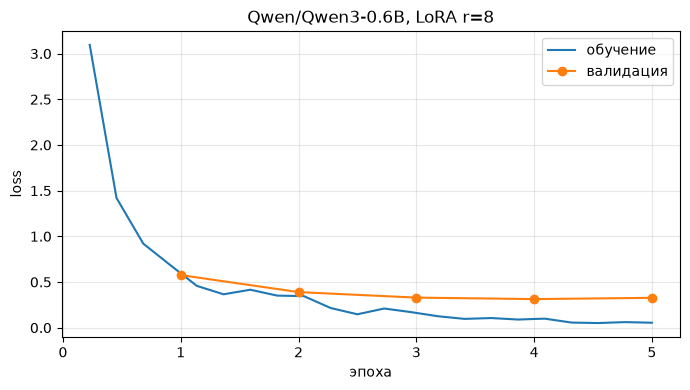

последний train loss: 0.05443182587623596
последний val loss:   0.326957643032074


In [29]:
if TRAIN_ADAPTER:
    plot_loss(
        history = history,
        rank = LORA_RANK,
        model_name = MODEL_NAME,
        training_dir = TRAINING_DIR,
    )

### Веса адаптера

При обучении веса сохраняются в `output/adapters`. При `TRAIN_ADAPTER=False` они скачиваются по ссылке с Google Drive (я выложил)

In [30]:
def save_adapter(*, model: PeftModel, adapter_dir: Path, drive_dir: Path | None) -> None:
    """Сохраняет веса адаптера и копирует их на Google Drive.

    Аргументы:
        model: обученная модель с адаптером.
        adapter_dir: каталог для весов.
        drive_dir: каталог на диске; None, если диск не подключён.

    Возвращает:
        Ничего, пишет файлы.
    """
    model.save_pretrained(str(adapter_dir))
    print("сохранено:", adapter_dir)

    if drive_dir is not None:
        import shutil

        shutil.copytree(adapter_dir, drive_dir, dirs_exist_ok = True)
        print("скопировано на диск:", drive_dir)


def attach_adapter(*, model, adapter_dir: Path) -> PeftModel:
    """Подключает сохранённые веса адаптера к базовой модели.

    Аргументы:
        model: базовая модель.
        adapter_dir: каталог с весами.

    Возвращает:
        Модель с адаптером в режиме вывода.
    """
    adapter_model = PeftModel.from_pretrained(model, str(adapter_dir))
    adapter_model.eval()
    print("веса подключены:", adapter_dir)
    return adapter_model

In [31]:
if TRAIN_ADAPTER:
    save_adapter(model = adapter_model, adapter_dir = ADAPTER_DIR, drive_dir = DRIVE_DIR)
else:
    if not (ADAPTER_DIR / "adapter_config.json").exists():
        if not ADAPTER_URL:
            raise ValueError("нет весов адаптера: заполните ADAPTER_URL или включите TRAIN_ADAPTER")
        !pip install -q gdown
        !gdown --folder -q "{ADAPTER_URL}" -O "{ADAPTER_DIR}"

    adapter_model = attach_adapter(model = model, adapter_dir = ADAPTER_DIR)

сохранено: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/adapters/qwen3-0.6b-r8


## 10. Прогон 3: адаптер

Тот же тест, та же генерация, тот же короткий промпт, что и в первом прогоне. Отличие одно — адаптер поверх базовых весов.

Сравнение с первым прогоном показывает, что дало обучение. Сравнение со вторым — что сильнее: правила в промпте или грамматика в весах.

In [32]:
LORA_TITLE = f"адаптер r={LORA_RANK}"

runs[LORA_TITLE] = run(
    title = LORA_TITLE,
    name = f"lora-r{LORA_RANK}",
    model = adapter_model,
    tokenizer = tokenizer,
    instruction = SHORT_PROMPT,
    records = test,
    batch_size = BATCH_SIZE,
    model_name = MODEL_NAME,
    runs_dir = RUNS_DIR,
)

print_metrics(metrics = runs[LORA_TITLE]["metrics"])

генерация: 100%|██████████| 17/17 [00:59<00:00,  3.52s/батч]

синтаксис      0.941    64 из 68
логика         0.191    13 из 68
сущность       0.838    57 из 68
поля           0.412    28 из 68
операторы      0.397    27 из 68
значения       0.265    18 из 68
суффикс        0.765    52 из 68
галлюцинации   0.029     2 из 68
строка         0.118     8 из 68
ответов        68


Ответы адаптера рядом с эталонами.

In [33]:
from ecql_dataset.notebook.eval.product import judge

lora_answers = runs[LORA_TITLE]["predictions"]

for record, prediction in list(zip(test, lora_answers))[:8]:
    verdict = judge(prediction = prediction, reference = record["output"])
    if verdict.exact:
        mark = "совпал"
    elif verdict.logic:
        mark = "смысл тот же, форма другая"
    else:
        mark = f"разошёлся: {verdict.reason}"
    print(record["input"])
    print("эталон:", record["output"])
    print("ответ: ", prediction, f"({mark})")
    print()

Хочу почитать отзывы по Пятигорску и Лермонтову.
эталон: FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов'
ответ:  FETCH [REVIEWS] WHERE @city IS 'Пятигорск' || @city IS 'Лермонтов' (совпал)

Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  FETCH [FARES] WHERE @transport IS 'tram' && @price_rub BETWEEN 20 && 40 AS LIST (разошёлся: условие не разбирается: '@price_rub BETWEEN 20')

Что в отзывах на «Оазис» говорят о чистоте?
эталон: FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:  FETCH [REVIEWS] WHERE @city IS 'Оазис' && @aspects CONTAINS 'чистота' (разошёлся: не совпало: поля, операторы, значения)

Кому из хостелов поставили три балла?
эталон: FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
ответ:  FETCH [REVIEWS] WHERE @rating IS 3 && @object_class IS 'hostel' AS LIST (разошёлся: не совпало: суффикс)

Что в Кислово

## 11. Сводная таблица по трем прогонам

Последний столбец - разница между адаптером и базой с полным промптом в процентных пунктах.

In [34]:
def print_summary(
    *,
    runs: dict,
    baseline: str,
    target: str,
    answers_delta_for: str,
    column_width: int,
) -> None:
    """Печатает метрики всех прогонов одной таблицей: строка - метрика, столбец - прогон.

    Последний столбец - насколько целевой прогон обошёл базовый, в процентных пунктах.
    У метрики `answers_delta_for` та же разница дополнительно показана числом ответов.

    Аргументы:
        runs: соответствие «имя прогона - результат прогона».
        baseline: имя прогона, с которым сравнивают.
        target: имя прогона, который сравнивают.
        answers_delta_for: имя метрики, у которой разница дублируется числом ответов.
        column_width: ширина столбца прогона в знаках.

    Возвращает:
        Ничего, печатает таблицу.
    """
    titles = list(runs)
    names = [name for name in runs[titles[0]]["metrics"] if name != "ответов"]

    baseline_metrics = runs[baseline]["metrics"]
    target_metrics = runs[target]["metrics"]

    header = "".join(f"{title:>{column_width}}" for title in titles)
    print(f"{'метрика':14}{header}{'Δ п.п.':>12}")

    for name in names:
        values = "".join(f"{runs[title]['metrics'][name]:>{column_width}.3f}" for title in titles)
        difference = (target_metrics[name] - baseline_metrics[name]) * 100
        line = f"{name:14}{values}{difference:>+12.1f}"

        if name == answers_delta_for:
            total = target_metrics["ответов"]
            answers = round(target_metrics[name] * total) - round(baseline_metrics[name] * total)
            line += f"   {answers:+} ответов из {total}"

        print(line)

    counts = "".join(f"{runs[title]['metrics']['ответов']:>{column_width}}" for title in titles)
    print(f"{'ответов':14}{counts}")


print_summary(
    runs = runs,
    baseline = BASE_FULL_TITLE,
    target = LORA_TITLE,
    answers_delta_for = "логика",
    column_width = 22,
)

метрика        база, короткий промпт   база, полный промпт           адаптер r=8      Δ п.п.
синтаксис                      0.000                 0.882                 0.941        +5.9
логика                         0.000                 0.059                 0.191       +13.2   +9 ответов из 68
сущность                       0.000                 0.574                 0.838       +26.5
поля                           0.000                 0.221                 0.412       +19.1
операторы                      0.000                 0.221                 0.397       +17.6
значения                       0.000                 0.132                 0.265       +13.2
суффикс                        0.000                 0.206                 0.765       +55.9
галлюцинации                   0.706                 0.265                 0.029       -23.5
строка                         0.000                 0.059                 0.118        +5.9
ответов                           68               

+6% по синтаксису языка

+13% идеальных ответов (было +20% до последних правок датасета, а я вроде 1 цифру только поправил, ну ладно....)

-24% ответов с галлюцинациями

настолько лучше с адаптером чем промптованная необученная модель

## 13. Разбор расхождений в 3х кейсах


In [35]:
lora = runs[LORA_TITLE]

wrong_answers = [
    (record, prediction, verdict)
    for record, prediction, verdict in zip(test, lora["predictions"], lora["verdicts"])
    if not verdict.logic
]

for record, prediction, verdict in wrong_answers[:8]:
    print(record["input"])
    print("эталон: ", record["output"])
    print("ответ:  ", prediction)
    print("причина:", verdict.reason)
    print()

Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон:  FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:   FETCH [FARES] WHERE @transport IS 'tram' && @price_rub BETWEEN 20 && 40 AS LIST
причина: условие не разбирается: '@price_rub BETWEEN 20'

Что в отзывах на «Оазис» говорят о чистоте?
эталон:  FETCH [REVIEWS] WHERE @name IS 'Оазис' && @aspects CONTAINS 'чистота'
ответ:   FETCH [REVIEWS] WHERE @city IS 'Оазис' && @aspects CONTAINS 'чистота'
причина: не совпало: поля, операторы, значения

Кому из хостелов поставили три балла?
эталон:  FETCH [REVIEWS] WHERE @object_class IS 'hostel' && @rating IS 3
ответ:   FETCH [REVIEWS] WHERE @rating IS 3 && @object_class IS 'hostel' AS LIST
причина: не совпало: суффикс

Что в Кисловодске идёт со средним чеком выше 200 рублей?
эталон:  FETCH [PLACES] WHERE @price_kind IS 'average_check' && @price_rub ABOVE 200 && @city IS 'Кисловодск'
ответ:   FETCH [PLACES] WHERE @price_rub ABOVE 200 && @price_

**Посмотрим на три разошедшихся ответа (ДЗ просит)**

**1. Оператор, которого в языке нет**

```
Ищу поездку на трамвае за 20-40 рублей, покажи варианты.
эталон: FETCH [FARES] WHERE @transport IS 'tram' && @price_rub ABOVE 20 && @price_rub BELOW 40
ответ:  FETCH [FARES] WHERE @transport IS 'tram' && @price_rub BETWEEN 20 && 40
```

В ECQL диапазон записывается двумя условиями по одному полю: `ABOVE` нижней границы и `BELOW` верхней. Модель написала `BETWEEN` - оператор SQL.

Такая форма в обучающей части редкая: диапазон встречается в 17 парах из 176. При этом `BETWEEN` попадается и у базовой модели с полным промптом, где правила языка перечислены словами. Значит это не пробел обучения, а привычка из предобучения: SQL модель видела несравнимо больше, чем ECQL, и обучение на 176 парах её не перебило.

**2. Потерянное условие**

```
Найди отзывы на два балла, где парковку обсуждают, а шум не упоминают.
эталон: FETCH [REVIEWS] WHERE @aspects CONTAINS 'парковка' && @rating IS 2 && @aspects NOT CONTAINS 'шум'
ответ:  FETCH [REVIEWS] WHERE @aspects NOT CONTAINS 'шум' && @rating IS 2
```

Из трёх условий модель вернула два: рейтинг и запрет на шум, но требование про парковку выбросила. Оба условия по `@aspects` относятся к одному полю, и модель оставила по нему одно.

Ответов, где условий меньше эталона, 17 из 68. У базы с полным промптом их 28 - обучение сократило потери, но каждый четвёртый ответ по-прежнему короче нужного.

**3. Похожее значение**

```
Нужны отзывы на отели, санатории и гостевые дома.
эталон: FETCH [REVIEWS] WHERE @object_class IS 'hotel' || @object_class IS 'sanatorium' || @object_class IS 'guesthouse'
ответ:  FETCH [REVIEWS] WHERE @object_class IS 'hotel' || @object_class IS 'sanatorium' || @object_class IS 'hostel'
```

Запрос построен верно: та же сущность, то же поле, тот же оператор, три условия через `||`. Разошлось одно значение - вместо `guesthouse` подставлен `hostel`.

Оба значения есть в перечне `@object_class` и оба означают жильё. `guesthouse` это гостевой дом, `hostel` это хостел. Сущность и поля модель берёт, а внутри перечня промахивается. Поэтому метрика `значения` ниже прочих частей логики

## 14. Второй ранг: r=4

Задание спрашивает, как ранг адаптера влияет на точность. Уменьшим ранг до 4 и проверим.

In [36]:
SMALL_RANK = 4

# Ссылка на веса для TRAIN_ADAPTER=False.
SMALL_ADAPTER_URL = "https://drive.google.com/drive/folders/1hgDSxBatX_-AWEab8QYdTPMwKFPmf754?usp=sharing"

SMALL_ADAPTER_DIR, SMALL_TRAINING_DIR, SMALL_DRIVE_DIR = prepare_output(
    adapter_name = f"qwen3-0.6b-r{SMALL_RANK}",
    output = OUTPUT,
    drive_root = DRIVE_ROOT,
)

print("веса адаптера:", SMALL_ADAPTER_DIR)
print("ход обучения:", SMALL_TRAINING_DIR)

веса адаптера: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/adapters/qwen3-0.6b-r4
ход обучения: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/training/qwen3-0.6b-r4


In [37]:
import gc


def allocated_memory(*, device: str) -> float:
    """Возвращает объём занятой памяти устройства.

    Аргументы:
        device: имя устройства.

    Возвращает:
        Занятая память в гигабайтах; ноль, если устройство её не сообщает.
    """
    if device == "cuda":
        return torch.cuda.memory_allocated() / 1e9
    if device == "mps":
        return torch.mps.driver_allocated_memory() / 1e9
    return 0.0

In [38]:
before = allocated_memory(device = DEVICE)

adapter_model = None
model = None

gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
elif DEVICE == "mps":
    torch.mps.empty_cache()

print(f"память: было {before:.1f} ГБ, стало {allocated_memory(device = DEVICE):.1f} ГБ")

model, tokenizer = load_model(model_name=MODEL_NAME, device=DEVICE, dtype=DTYPE, load_in_4bit=LOAD_IN_4BIT)

print("база загружена заново:", model.device)

память: было 14.8 ГБ, стало 0.0 ГБ


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 6077.65it/s]


база загружена заново: mps:0


### Обучение

In [39]:
if TRAIN_ADAPTER:
    small_adapter_model, small_history = train_adapter(
        model = model,
        tokenizer = tokenizer,
        train_dataset = train_dataset,
        val_dataset = val_dataset,
        lora_config = create_lora_config(rank = SMALL_RANK),
        training_config = create_training_config(
            training_dir = SMALL_TRAINING_DIR,
            batch_size = BATCH_SIZE,
            effective_batch = EFFECTIVE_BATCH,
            epochs = EPOCHS,
        ),
    )

Truncating train dataset: 100%|██████████| 176/176 [00:00<00:00, 9669.11 examples/s]
Dropping fully masked examples from train dataset: 100%|██████████| 176/176 [00:00<00:00, 16981.38 examples/s]
Dropping fully masked examples from eval dataset: 100%|██████████| 32/32 [00:00<00:00, 12577.80 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


trainable params: 2,523,136 || all params: 598,573,056 || trainable%: 0.4215


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.939893,0.742343,0.902553,233956.000000,0.807555
2,0.411839,0.467280,0.443584,467912.000000,0.864068
3,0.272737,0.376280,0.343599,701868.000000,0.887044
4,0.163865,0.350439,0.268894,935824.000000,0.896262
5,0.107077,0.347710,0.246540,1169780.000000,0.896526


/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/.venv/lib/python3.13/site-packages/torch/utils/data/da

**Результат:**
Validation Loss выше и падает медленнее - в течении 5 эпох (ранг=4) вместо 3х/4х (ранг=8)

Меньше ранг -> меньше весов для дообучения и модели нужно больше итераций чтобы подстроится под задачу.


У меня максимум 5 эпох потому что на более ранних тестах, когда я ставил 7 - максимум был на 3-4 эпохе.

### График loss

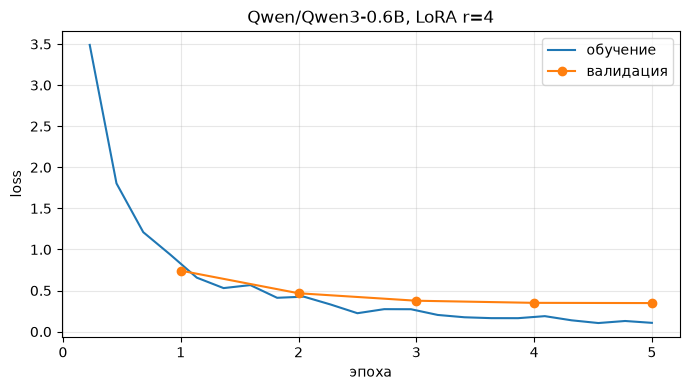

последний train loss: 0.10707678794860839
последний val loss:   0.34770962595939636


In [40]:
if TRAIN_ADAPTER:
    plot_loss(
        history = small_history,
        rank = SMALL_RANK,
        model_name = MODEL_NAME,
        training_dir = SMALL_TRAINING_DIR,
    )

### Веса адаптера

In [41]:
if TRAIN_ADAPTER:
    save_adapter(
        model = small_adapter_model,
        adapter_dir = SMALL_ADAPTER_DIR,
        drive_dir = SMALL_DRIVE_DIR,
    )
else:
    if not (SMALL_ADAPTER_DIR / "adapter_config.json").exists():
        !pip install -q gdown
        !gdown --folder -q "{SMALL_ADAPTER_URL}" -O "{SMALL_ADAPTER_DIR}"

    small_adapter_model = attach_adapter(model = model, adapter_dir = SMALL_ADAPTER_DIR)

сохранено: /Users/samtakot/devs/learnings/llm-eng/homework/llm-eng-21-training-metrics/output/adapters/qwen3-0.6b-r4


### Прогон 4 (test): адаптер r=4

Тот же тест и тот же короткий промпт, что у прогона 3.

In [42]:
SMALL_LORA_TITLE = f"адаптер r={SMALL_RANK}"

runs[SMALL_LORA_TITLE] = run(
    title = SMALL_LORA_TITLE,
    name = f"lora-r{SMALL_RANK}",
    model = small_adapter_model,
    tokenizer = tokenizer,
    instruction = SHORT_PROMPT,
    records = test,
    batch_size = BATCH_SIZE,
    model_name = MODEL_NAME,
    runs_dir = RUNS_DIR,
)

print_metrics(metrics = runs[SMALL_LORA_TITLE]["metrics"])

генерация: 100%|██████████| 17/17 [00:50<00:00,  2.98s/батч]

синтаксис      0.912    62 из 68
логика         0.191    13 из 68
сущность       0.735    50 из 68
поля           0.338    23 из 68
операторы      0.324    22 из 68
значения       0.235    16 из 68
суффикс        0.721    49 из 68
галлюцинации   0.074     5 из 68
строка         0.147    10 из 68
ответов        68


### Четыре прогона рядом

Та же таблица, что в шаге 11, теперь с четырьмя столбцами. База сравнения сменилась: последний столбец показывает, что дал ранг 4 против ранга 8.

In [43]:
print_summary(
    runs = runs,
    baseline = LORA_TITLE,
    target = SMALL_LORA_TITLE,
    answers_delta_for = "логика",
    column_width = 22,
)

метрика        база, короткий промпт   база, полный промпт           адаптер r=8           адаптер r=4      Δ п.п.
синтаксис                      0.000                 0.882                 0.941                 0.912        -2.9
логика                         0.000                 0.059                 0.191                 0.191        +0.0   +0 ответов из 68
сущность                       0.000                 0.574                 0.838                 0.735       -10.3
поля                           0.000                 0.221                 0.412                 0.338        -7.4
операторы                      0.000                 0.221                 0.397                 0.324        -7.4
значения                       0.000                 0.132                 0.265                 0.235        -2.9
суффикс                        0.000                 0.206                 0.765                 0.721        -4.4
галлюцинации                   0.706                 0.265   

**Результат:**

При уменьшении ранга с 8 до 4 все метрики немного просели, галлюцинации чуть подросли, но все примерно одинаково.

Главная метрика **логика** в последнем прогоне не изменилась при понижении ранга.

## 15. Отчёт

Выводы по вопросам ДЗ и ссылки на веса адаптеров тут — [docs/REPORT.md](https://github.com/samtakoy/llm-engineer-ecql-and-metrcis/blob/main/docs/REPORT.md).